<div style="
  background: linear-gradient(135deg, #105666 0%, #0a2e38 100%);
  border-radius: 14px;
  padding: 36px 40px;
  font-family: 'Georgia', serif;
  margin: 12px 0;
  box-shadow: 0 8px 32px rgba(16,86,102,0.3);
  position: relative;
  overflow: hidden;
">
  <div style="position:absolute; top:-30px; right:-30px; width:180px; height:180px;
    border-radius:50%; background:rgba(211,150,140,0.08);"></div>
  <div style="position:absolute; bottom:-50px; left:20px; width:120px; height:120px;
    border-radius:50%; background:rgba(211,150,140,0.05);"></div>
  <p style="color:#D3968C; font-size:11px; letter-spacing:4px; text-transform:uppercase;
    margin:0 0 6px 0; font-family:monospace;">
    Universidad de San Andrés · Sistemas de Control
  </p>
  <h1 style="color:#f5ede8; font-size:2em; margin:0 0 6px 0; font-weight:300; letter-spacing:-0.5px;">
    Trabajo Práctico N°1
  </h1>
  <h2 style="color:#a8cdd4; font-size:1.1em; font-weight:300; margin:0 0 20px 0;">
    Diseño de Controladores con Root Locus y Respuesta en Frecuencia
  </h2>
  <div style="display:flex; gap:24px; flex-wrap:wrap;">
    <span style="background:rgba(211,150,140,0.15); border:1px solid rgba(211,150,140,0.3);
      color:#D3968C; padding:5px 14px; border-radius:20px; font-family:monospace; font-size:0.75em;">
      Manuela Gomez Pazos · Ticiana Verdun · Zöe Velazquez Zorzi ·
    </span>
    <span style="background:rgba(168,205,212,0.1); color:#a8cdd4;
      padding:5px 14px; border-radius:20px; font-family:monospace; font-size:0.75em;">
      Abril 2026
    </span>
  </div>
</div>

<div style="
  background: #0d3d4a;
  border-radius: 12px;
  padding: 24px 28px;
  font-family: 'Georgia', serif;
  margin: 16px 0;
  max-width: 480px;
">
  <p style="color:#D3968C; font-size:0.7em; letter-spacing:3px; text-transform:uppercase; margin:0 0 16px 0; font-family:monospace;">
    Índice
  </p>
  <ol style="color:#c8e8ed; padding-left:20px; margin:0; line-height:2.2em; font-size:0.95em;">
    <li>Sistema de Control de un Rotor de Aspas</li>
    <li>Análisis y Control frente a Perturbaciones</li>
  </ol>
</div>

In [2]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

<div style="display:flex; align-items:center; gap:14px; margin:24px 0;">
  <div style="height:2px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <span style="
    background:#105666;
    color:#f5ede8;
    font-family:'Georgia',serif;
    font-size:0.75em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:6px 18px;
    border-radius:20px;
  ">Primera parte</span>
  <div style="height:2px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

<div style="
  background: #fff8f6;
  border: 1.5px solid #D3968C;
  border-radius: 10px;
  padding: 16px 20px;
  margin: 12px 0;
  font-family: Georgia, serif;
">

  <!-- Header -->
  <div style="margin-bottom: 10px;">
    <span style="
      display: inline-block;
      background:#D3968C;
      color:#ffffff;
      border-radius:50%;
      width:24px;
      height:24px;
      text-align:center;
      line-height:24px;
      font-family: monospace;
      font-size: 12px;
      font-weight: bold;
      margin-right:8px;
    ">1</span>
    <span style="
      color:#8a4a3e;
      font-size: 11px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      font-family: monospace;
    ">
      Ejercicio 1: Sistema de Control de un rotor de aspas
    </span>
  </div>

  <!-- Body -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0 0 12px 0;
  ">
    En muchas aeronaves de despegue y aterrizaje vertical (VTOL), los sistemas de propulsión deben operar bajo distintos modos de funcionamiento a lo largo del vuelo. Durante el despegue y el ascenso vertical, el motor eléctrico controla el régimen de rotación de la hélice para generar el empuje necesario. 
    Sin embargo, una vez que la aeronave entra en modo avión y comienza el vuelo hacia adelante, puede ser conveniente modificar la orientación de la hélice para reducir la resistencia aerodinámica.
  </p>

  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0 0 12px 0;
  ">
    En particular, cuando el motor no se utiliza para generar empuje, es posible alinear las palas con la dirección del flujo incidente. Esto reduce significativamente el drag aerodinámico producido por la hélice durante el vuelo de crucero.
  </p>

  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0 0 12px 0;
  ">
    El motor que controla el sistema de la hélice puede entonces operar en dos modos:
  </p>

  <!-- List -->
  <ul style="margin-top:0; margin-bottom:12px; padding-left:18px;">
    <li style="margin-bottom:6px;">
      <code style="background:#f5ede8; color:#5a2a1a; padding:2px 6px; border-radius:4px;">
        Modo Propulsión
      </code>: donde se regula la velocidad de rotación del motor.
    </li>
    <li>
      <code style="background:#f5ede8; color:#5a2a1a; padding:2px 6px; border-radius:4px;">
        Modo Orientación
      </code>: donde se controla la posición angular del mecanismo para alinear la hélice con el flujo.
    </li>
  </ul>

  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0;
  ">
    En ambos casos, el sistema puede experimentar perturbaciones debidas a variaciones en la carga aerodinámica, cambios en el flujo de aire o efectos transitorios durante la transición entre modos de vuelo.
    En este ejercicio se analizará el modelo dinámico de un motor de corriente continua que acciona este mecanismo y se diseñará un sistema de control capaz de seguir una referencia de posición angular y rechazar perturbaciones externas.
  </p>

</div>

<div style="
  background: #f7fbff;
  border: 1.5px solid #7aa6d6;
  border-radius: 10px;
  padding: 16px 20px;
  margin: 12px 0;
  font-family: Georgia, serif;
">

  <!-- Header -->
  <div style="margin-bottom: 10px;">
    <span style="
      display: inline-block;
      background:#7aa6d6;
      color:#ffffff;
      border-radius:50%;
      width:24px;
      height:24px;
      text-align:center;
      line-height:24px;
      font-family: monospace;
      font-size: 12px;
      font-weight: bold;
      margin-right:8px;
    ">⚙</span>
    <span style="
      color:#3b5f8a;
      font-size: 11px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      font-family: monospace;
    ">
      Dinámica del sistema
    </span>
  </div>

  <!-- Intro -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0 0 12px 0;
  ">
    La dinámica del motor de corriente continua se describe mediante el siguiente sistema de ecuaciones diferenciales:
  </p>

  <!-- Equations -->
  <div style="
    background:#eef5fb;
    border-radius:8px;
    padding:10px 14px;
    font-family: monospace;
    font-size: 13px;
    margin-bottom:12px;
  ">
    (1) &nbsp; L · di(t)/dt + R · i(t) + Ke · ω(t) = V(t) <br>
    (2) &nbsp; J · dω(t)/dt + B · ω(t) = τm(t) = Kt · i(t) <br>
    (3) &nbsp; ω(t) = dθ(t)/dt
  </div>

  <!-- Variables -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    margin-bottom:6px;
  "><b>Donde:</b></p>

  <ul style="margin-top:0; margin-bottom:12px; padding-left:18px; font-size:14px;">
    <li>θ(t): ángulo de posición del aspa [rad]</li>
    <li>ω(t): velocidad angular [rad/s]</li>
    <li>i(t): corriente de armadura [A]</li>
    <li>V(t): tensión aplicada [V]</li>
  </ul>

  <!-- Parameters -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    margin-bottom:6px;
  "><b>Parámetros del sistema:</b></p>

  <ul style="margin-top:0; margin-bottom:12px; padding-left:18px; font-size:14px;">
    <li>L = 0.15 H (inductancia)</li>
    <li>R = 0.7 Ω (resistencia)</li>
    <li>Ke = 0.1 V·s/rad (fem)</li>
    <li>J = 0.02 kg·m² (inercia)</li>
    <li>B = 0.25 N·m·s/rad (fricción viscosa)</li>
    <li>Kt = 0.25 N·m/A (constante de torque)</li>
  </ul>

  <!-- Explanation -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0;
  ">
    Las Ecs. (1)-(3) corresponden al típico modelo del motor de continua o DC que se observa en la Fig. 1. En este se puede ver que la tensión V (t) produce una corriente que circula por una bobina (que representa el bobinado de la armadura del motor) y que genera también una diferencia de potencial en el rotor. Esta corriente será directamente proporcional al torque que genera el motor, mientras que la tensión sobre el rotor será directamente proporcional a la velocidad de giro del rotor.
  </p>

</div>

<div style="
  background: #fff8f6;
  border: 1.5px solid #D3968C;
  border-radius: 10px;
  padding: 16px 20px;
  margin: 12px 0;
  font-family: Georgia, serif;
">

  <!-- Header -->
  <div style="margin-bottom: 10px;">
    <span style="
      display: inline-block;
      background:#D3968C;
      color:#ffffff;
      border-radius:50%;
      width:24px;
      height:24px;
      text-align:center;
      line-height:24px;
      font-family: monospace;
      font-size: 12px;
      font-weight: bold;
      margin-right:8px;
    ">A</span>
    <span style="
      color:#8a4a3e;
      font-size: 11px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      font-family: monospace;
    ">
      Análisis del sistema
    </span>
  </div>

  <!-- Body -->
  <p style="
    color:#1a1a1a;
    font-size: 14px;
    line-height: 1.6;
    margin: 0 0 12px 0;
  ">
    En esta parte del trabajo, deberá analizar el sistema para poder entender sus limitaciones y concluir sobre un controlador que puede resolver el problema planteado.
  </p>

  <!-- Lettered List -->
  <ol type="a" style="
    margin-top:0;
    margin-bottom:12px;
    padding-left:22px;
    color:#000000;
    font-size:14px;
  ">
    <li style="margin-bottom:6px; color:#000000;">
      Encontrar la función de transferencia G(s)= Θ(s)/V(s) y las ecuaciones en variables de estado para el motor de DC.
    </li>
    <li style="margin-bottom:6px; color:#000000;">
      Considere la planta G(s) obtenida en el punto anterior, calcule el margen de ganancia y el margen de fase a lazo abierto. Concluya si es necesario introducir un compensador.
    </li>
    <li style="margin-bottom:6px; color:#000000;">
      Considere el sistema en lazo cerrado con realimentación unitaria. Analice el efecto de una perturbación de carga constante de magnitud 0.1 (escalón de altura 0.1). Encuentre la transferencia Θ(s)/N(s), donde N(s) es la transformada de Laplace de la perturbación de carga. Grafique la salida del sistema considerando simultáneamente la perturbación y la entrada de referencia. Incluya también la referencia (escalón unitario) en la gráfica.
    </li>
    <li style="margin-bottom:6px; color:#000000;">
      Repita el punto anterior considerando la misma perturbación de carga. En este caso, utilice una referencia tipo rampa unitaria. Grafique la referencia junto con la salida del sistema.
    </li>
    <li style="color:#000000;">
      Para cada uno de los casos analizados previamente (referencia escalón y referencia rampa, ambos con perturbación de carga constante), proponga qué tipo de controlador (PID, compensador lead, lag, etc.) debería introducirse para mejorar el desempeño del sistema. Justifique su elección en función del error en régimen permanente, el rechazo de perturbaciones y los márgenes de estabilidad.
    </li>

  </ol>

</div>

<div style="
  background: #105666;
  border-radius: 12px;
  padding: 24px 28px;
  margin: 16px 0;
  font-family: 'Georgia', serif;
  display: flex;
  align-items: flex-start;
  gap: 18px;
  box-shadow: 0 4px 16px rgba(16,86,102,0.2);
">
  <div>
    <p style="color:#D3968C; font-size:0.7em; letter-spacing:3px; text-transform:uppercase; margin:0 0 8px 0; font-family:monospace;">
      Aclaración!
    </p>
    <p style="color:#e8f4f6; font-size:1em; line-height:1.7; margin:0;">
      A lo largo de este notebook estará la implementación en código necesaria para resolver los ejercicios del trabajo práctico. Por una cuestión de practicidad, los desarrollos matemáticos completos, se van a encontrar en detalle en el informe y no aquí.
    </p>
  </div>
</div>

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso a</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Función de transferencia y variables de estado

Aplicando Laplace a las ecuaciones del motor y despejando $\Theta(s)/V(s)$, se obtiene una planta de **tipo 1** (polo en el origen). La misma dinámica se expresa en variables de estado con $x = [\theta,\ \omega,\ i]^T$, verificando que $C(sI-A)^{-1}B$ reproduce la misma $G(s)$.

In [3]:
L = 0.15
R = 0.7
K_e = 0.1
J = 0.02
B = 0.25
K_t = 0.25

# Funcion de transferencia
G = ctrl.tf([K_t], [L*J, J*R + B*L, B*R + K_e*K_t, 0])

# Forma matricial
A = np.array ([[0, 1, 0], [0, -B/J, K_t/J], [0, -K_e/L, -R/L]])
B = np.array ([[0], [0], [1/L]])
C = np.array ([[1, 0, 0]])
D = np.array ([[0]])

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso b</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

Los márgenes de estabilidad miden qué tan lejos está el sistema de volverse inestable. Los calculamos sobre la función de transferencia a lazo abierto G(s).

Margen de Fase (MF): cuántos grados de fase adicional podemos agregar antes de llegar a la inestabilidad. Se mide en la frecuencia de cruce de ganancia ωcg (donde |G(jω)| = 1).
Margen de Ganancia (MG): cuánto podés aumentar la ganancia antes de inestabilizar. Se mede en la frecuencia de cruce de fase ωcp (donde ∠G(jω) = −180°).

Para que el sistema sea estable (fase mínima): MF > 0° y MG > 0 dB.

### Cálculo analítico

La función de transferencia obtenida es:

$$
G(s) = \frac{K_t}{s\bigl(LJ s^2 + (JR + BL)s + (BR + K_e K_t)\bigr)}
$$

Si sustituímos los valores numéricos del enunciado:

$$
G(s) = \frac{0.25}{s\left(0.003\,s^2 + 0.0515\,s + 0.200\right)}
$$

---

### Análisis del sistema

- El sistema es de **tipo 1**, ya que tiene un polo en el origen ($s = 0$).
- Esto implica que la **fase inicial** es de aproximadamente $-90^\circ$.
- La función tiene **3 polos en total**, por lo que:

$$
\lim_{\omega \to \infty} \angle G(j\omega) = -270^\circ
$$

---

### Conclusión

Como la fase comienza en $-90^\circ$ y tiende a $-270^\circ$, necesariamente:

- Existe una frecuencia donde la fase alcanza $-180^\circ$
- Por lo tanto, el sistema tiene un **margen de ganancia finito**

Margen de Ganancia: 22.76 dB  (en ωcp = 8.16 rad/s)
Margen de Fase:     72.22°  (en ωcg = 1.22 rad/s)


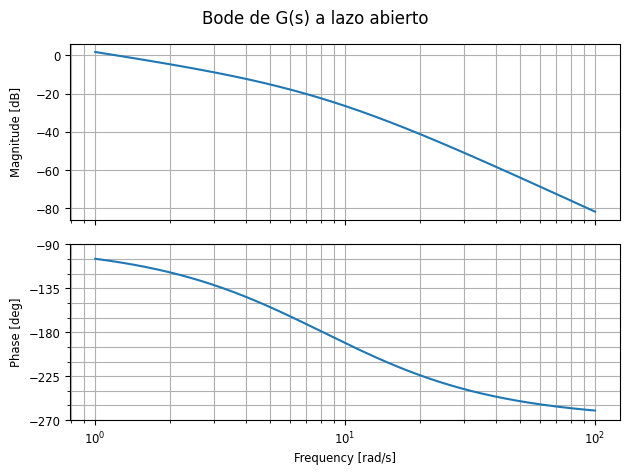

In [ ]:
# Parámetros del enunciado!
L = 0.15; R = 0.7; K_e = 0.1
J = 0.02; B = 0.25; K_t = 0.25

# Función de transferencia que calculamos
G = ctrl.tf([K_t], [L*J, J*R + B*L, B*R + K_e*K_t, 0])

# Márgenes
gm, pm, wcp, wcg = ctrl.margin(G)
gm_dB = 20 * np.log10(gm)

print(f"Margen de Ganancia: {gm_dB:.2f} dB  (en ωcp = {wcp:.2f} rad/s)")
print(f"Margen de Fase:     {pm:.2f}°  (en ωcg = {wcg:.2f} rad/s)")

ctrl.bode(G, dB=True)
plt.suptitle("Bode de G(s) a lazo abierto")
plt.show()

### Conclusión sobre la necesidad de compensador

Los márgenes obtenidos son:

- **Margen de Fase:** 72.22° (en ωcg = 1.22 rad/s)
- **Margen de Ganancia:** 22.76 dB (en ωcp = 8.16 rad/s)

Ambos superan los valores recomendados (MF entre 30°–60°, MG > 6 dB).
El sistema es estable en lazo cerrado sin compensación.

Sin embargo, el MF elevado indica un sistema **muy amortiguado y posiblemente lento**,
lo que puede dificultar cumplir con las especificaciones de tiempo de establecimiento
requeridas en la Parte B. Esto motivará el diseño de un compensador más adelante.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso c</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Escalón unitario + perturbación constante de 0.1

La perturbación entra en el nodo mecánico, después del integrador de la planta. El tipo 1 garantiza $e_{ss}=0$ ante la referencia escalón, pero la perturbación produce un error permanente de **0.07 rad** (TVF: $0.1 \times K_tR/(RB+K_eK_t) = 0.07$).

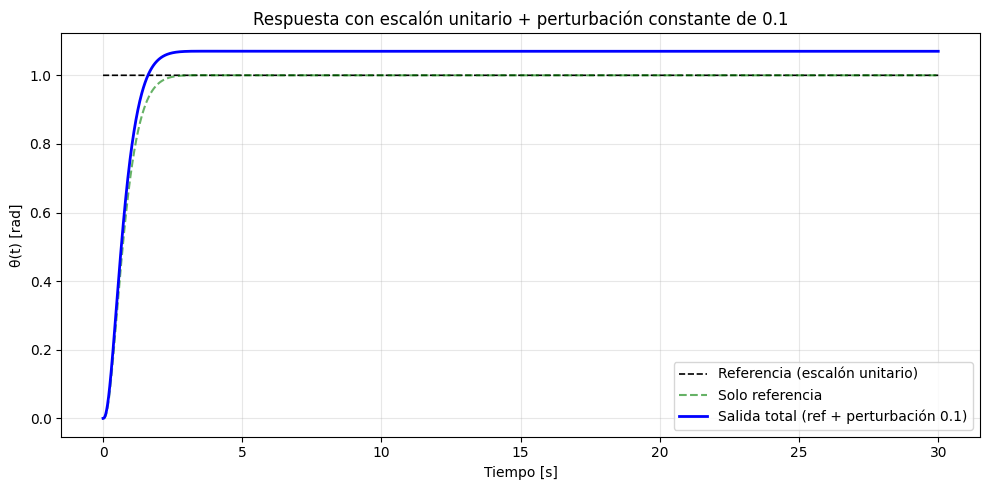

θ(∞) referencia:   1.0000 rad  (esperado: 1.0000)
θ(∞) perturbación: 0.0700 rad  (esperado: 0.0700)
Error permanente:  0.0700 rad


In [ ]:
L, R, Ke, J, B, Kt = 0.15, 0.7, 0.1, 0.02, 0.25, 0.25

G    = ctrl.tf([Kt], [L*J, L*B+R*J, R*B+Ke*Kt, 0])
G_cl = ctrl.feedback(G, 1)

# T_N derivada analíticamente: Θ(s)/N(s) = Kt(Ls+R) / [LJs³+(LB+RJ)s²+(RB+KeKt)s+Kt]
T_N = ctrl.tf([Kt*L, Kt*R], [L*J, L*B+R*J, R*B+Ke*Kt, Kt])

t = np.linspace(0, 30, 3000)

_, y_ref  = ctrl.step_response(G_cl, T=t)
_, y_pert = ctrl.step_response(0.1 * T_N, T=t)
y_total   = y_ref + y_pert

plt.figure(figsize=(10, 5))
plt.plot(t, np.ones_like(t), 'k--', lw=1.2, label='Referencia (escalón unitario)')
plt.plot(t, y_ref,   'g--', alpha=0.6, label='Solo referencia')
plt.plot(t, y_total, 'b',   lw=2,     label='Salida total (ref + perturbación 0.1)')
plt.xlabel('Tiempo [s]')
plt.ylabel('θ(t) [rad]')
plt.title('Respuesta con escalón unitario + perturbación constante de 0.1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"θ(∞) referencia:   {y_ref[-1]:.4f} rad  (esperado: 1.0000)")
print(f"θ(∞) perturbación: {y_pert[-1]:.4f} rad  (esperado: 0.0700)")
print(f"Error permanente:  {y_total[-1] - 1:.4f} rad")

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso d</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

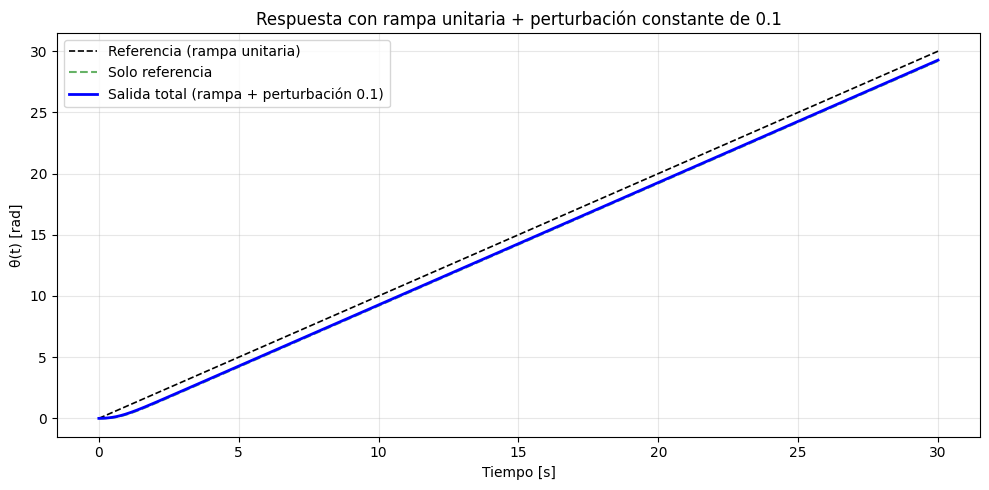

Error por rampa en régimen permanente:        0.8000 rad  (esperado: 0.8000)
Error por perturbación en régimen permanente: 0.0700 rad  (esperado: 0.0700)
Error total en régimen permanente:            0.7300 rad


In [ ]:
t = np.linspace(0, 30, 3000)
rampa = t

# Respuesta ante rampa
_, y_r = ctrl.forced_response(G_cl, T=t, U=rampa)

# Perturbación constante
_, y_pert = ctrl.step_response(0.1 * T_N, T=t)

y_total = y_r + y_pert

plt.figure(figsize=(10, 5))
plt.plot(t, rampa,   'k--', lw=1.2, label='Referencia (rampa unitaria)')
plt.plot(t, y_r,     'g--', alpha=0.6, label='Solo referencia')
plt.plot(t, y_total, 'b',   lw=2,   label='Salida total (rampa + perturbación 0.1)')
plt.xlabel('Tiempo [s]')
plt.ylabel('θ(t) [rad]')
plt.title('Respuesta con rampa unitaria + perturbación constante de 0.1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Error por rampa en régimen permanente:        {rampa[-1] - y_r[-1]:.4f} rad  (esperado: 0.8000)")
print(f"Error por perturbación en régimen permanente: {y_pert[-1]:.4f} rad  (esperado: 0.0700)")
print(f"Error total en régimen permanente:            {rampa[-1] - y_total[-1]:.4f} rad")

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso e</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

Podemos plantear 2 estrategias, según cuál sea la referencia
de operación del sistema:

Modo orientación con referencia escalón: nos alcanzaría con un controlador PD, que agrega un cero al lugar de las raíces y permite incrementar la ganancia del lazo sin deteriorar el transitorio.
Modo propulsión con referencia rampa: para este caso necesitamos un controlador PID, que incorpora un integrador adicional y lleva el sistema a ser de tipo 2, garantizando error nulo tanto ante escalón como ante rampa.

De nuevo, este tipo de análisis se lleva más a detalle en el informe.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso a</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

Con el análisis de la Parte A como punto de partida, se procede al diseño de un
controlador $C(s)$ que permita cumplir simultáneamente con los requisitos de
desempeño en lazo cerrado: tiempo de establecimiento $t_s \leq 7{,}5\,\text{s}$,
sobrepico $M_p \leq 15\,\%$, y error angular menor al $5\,\%$ ante una perturbación
de carga constante de magnitud $0{,}2$.

Se parte de los valores de $t_s$, $M_p$ y error en régimen permanente obtenidos
**sin compensación** ($C(s) = 1$), que sirven como referencia para cuantificar la
mejora introducida. El controlador se diseña mediante el método del **lugar de raíces**,
ubicando los polos dominantes de lazo cerrado en posiciones que satisfagan las
especificaciones. Una vez obtenido el compensador, se verifican los **márgenes de
ganancia y fase** en el diagrama de Bode, comparándolos con el caso no compensado.
Finalmente, se evalúa el seguimiento ante una **referencia tipo rampa**, y en caso
de que el error en régimen permanente no sea nulo, se introduce la modificación
necesaria al controlador para garantizar seguimiento exacto sin violar las
especificaciones previas.

#### Baseline sin compensación
 
Las tres especificaciones que nos dan  se traducen en restricciones sobre los
**polos dominantes** del sistema en lazo cerrado.
 
**Sobrepico** $M_p \leq 15\,\%$:
 
La fórmula exacta para un sistema de segundo orden es:
 
$$M_p = e^{-\pi\zeta/\sqrt{1-\zeta^2}} \times 100\,\%$$
 
Despejando $\zeta$ para $M_p = 15\,\%$:
 
$$\zeta \geq -\frac{\ln(0{,}15)}{\sqrt{\pi^2 + \ln^2(0{,}15)}} \approx 0{,}517$$
 
Esto nos da un **ángulo máximo** desde el eje real de $\cos^{-1}(0{,}517) \approx 58{,}9°$.
 
**Tiempo de establecimiento** $t_s \leq 7{,}5\,\text{s}$ (criterio 2 %):
 
Para un sistema de segundo orden, la aproximación estándar es:
 
$$t_s \approx \frac{4}{\zeta\,\omega_n} = \frac{4}{\sigma}$$
 
donde $\sigma = \zeta\,\omega_n$ es la parte real (en valor absoluto) de los polos dominantes. Entonces:
 
$$\sigma \geq \frac{4}{7{,}5} \approx 0{,}533\,\text{rad/s}$$
 
**Error ante perturbación constante de 0,2** $< 5\,\%$:
 
Por el **teorema del valor final**, el error en régimen permanente ante una perturbación
escalón $N(s) = 0{,}2/s$ es:
 
$$e_{ss} = \lim_{s \to 0}\; s \cdot \frac{\Theta(s)}{N(s)} \cdot \frac{0{,}2}{s}
         = 0{,}2 \cdot \frac{\Theta(s)}{N(s)}\bigg|_{s=0}$$
 
Con la transferencia perturbación–salida derivada en la Parte A:
 
$$\frac{\Theta(s)}{N(s)} = \frac{0{,}0375s + 0{,}175}{0{,}003s^3 + 0{,}0515s^2 + 0{,}2s + 0{,}25}$$
 
Evaluando en $s = 0$:
 
$$\frac{\Theta(0)}{N(0)} = \frac{0{,}175}{0{,}25} = 0{,}70$$
 
Por lo tanto, el error en régimen permanente ante $N = 0{,}2$ es:
 
$$\boxed{e_{ss} = 0{,}2 \times 0{,}70 = 0{,}14\,\text{rad} \quad (14\,\%)}$$
 
Este valor **supera el límite del 5 %**, confirmamos con esto la necesidad de un compensador.
 
---
 
### ¿Por qué ocurre este error ante perturbación?
 
El sistema es de **tipo 1** (tiene un integrador natural en $G(s)$, el polo en $s=0$).
Esto garantiza error nulo ante escalón de *referencia*, pero **no** garantiza rechazo
completo de una perturbación de carga constante, porque dicha perturbación entra
*después* del integrador de la planta.
 
Para reducir el error ante perturbación constante por debajo del 5 % vamos a necesitar sumar ganancia adicional o un polo en el origen en el controlador.

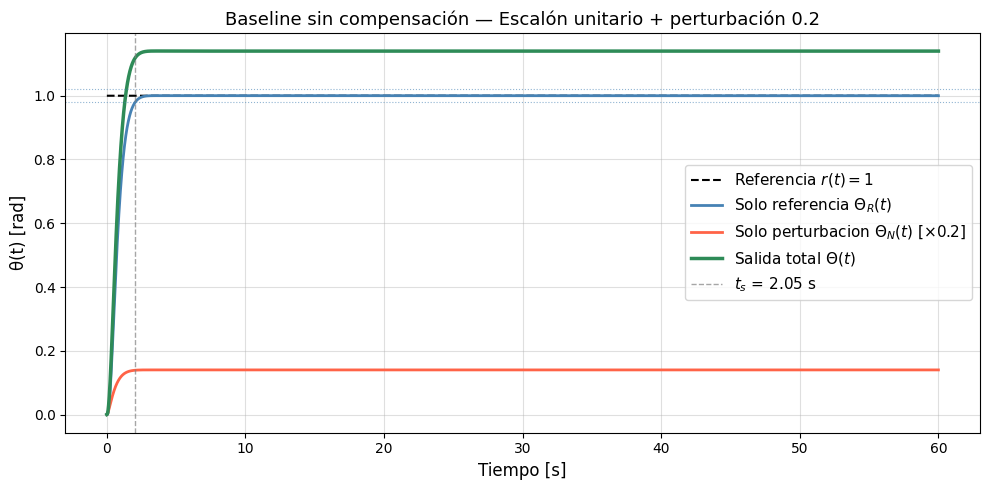

  BASELINE SIN COMPENSACION  (C(s) = 1)
  Sobrepico         Mp  = 0.02 %      (req: ≤ 15 %)
  Tiempo establec.  ts  = 2.05 s    (req: ≤ 7.5 s)
  Error pert. (0.2) ess = 0.1400 rad  (14.0 %)  (req: < 5 %)


In [ ]:
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25

G = ctrl.tf([Kt], [L*J,  J*R + B*L,  B*R + Ke*Kt,  0])
 
# lazo cerrado con C(s)=1 y realimentación unitaria 
G_cl = ctrl.feedback(G, 1)

num_TN = [Kt*L,  Kt*R]
den_TN = [L*J,  (L*B + R*J),  (R*B + Ke*Kt),  Kt]
T_N    = ctrl.tf(num_TN, den_TN)
 
# simulacion
t = np.linspace(0, 60, 10000)
 
_, y_ref  = ctrl.step_response(G_cl, T=t) # respuesta al escalon de ref
_, y_pert = ctrl.step_response(T_N,  T=t)
y_pert = 0.2 * y_pert # la perturbacion
 
y_total = y_ref + y_pert
 
# calculamos Mp
y_inf = y_ref[-1]
y_max = np.max(y_ref)
Mp = (y_max - y_inf) / y_inf * 100
 
# calculamos ts
banda_sup = y_inf * 1.02
banda_inf = y_inf * 0.98
fuera_banda = np.where((y_ref > banda_sup) | (y_ref < banda_inf))[0]
ts = t[fuera_banda[-1]] if len(fuera_banda) > 0 else 0.0
 
# error en régimen permanente ante perturbación 0.2
e_pert = y_pert[-1]
e_rel = abs(e_pert) / 1.0 * 100
 

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, np.ones_like(t), 'k--', lw=1.5, label='Referencia $r(t)=1$')
ax.plot(t, y_ref,    color='steelblue',  lw=2,   label='Solo referencia $\\Theta_R(t)$')
ax.plot(t, y_pert,   color='tomato',     lw=2,   label='Solo perturbacion $\\Theta_N(t)$ [×0.2]')
ax.plot(t, y_total,  color='seagreen',   lw=2.5, label='Salida total $\\Theta(t)$')
ax.axhline(banda_sup, color='steelblue', lw=0.8, ls=':', alpha=0.6)
ax.axhline(banda_inf, color='steelblue', lw=0.8, ls=':', alpha=0.6)
ax.axvline(ts, color='gray', lw=1, ls='--', alpha=0.7, label=f'$t_s$ = {ts:.2f} s')
ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('θ(t) [rad]', fontsize=12)
ax.set_title('Baseline sin compensación — Escalón unitario + perturbación 0.2', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
 
print("  BASELINE SIN COMPENSACION  (C(s) = 1)")
print(f"  Sobrepico         Mp  = {Mp:.2f} %      (req: ≤ 15 %)")
print(f"  Tiempo establec.  ts  = {ts:.2f} s    (req: ≤ 7.5 s)")
print(f"  Error pert. (0.2) ess = {e_pert:.4f} rad  ({e_rel:.1f} %)  (req: < 5 %)")


El sistema sin compensar cumple muy bien con el sobrepico y el tiempo de
establecimiento. Esto se explica por el del polo en $s = 0$ (integrador)
en la planta, que produce una respuesta suavemente amortiguada sin oscilaciones.
 
Sin embargo, **falla en la especificación de rechazo de perturbaciones**: el error
en régimen permanente ante una perturbación constante de 0,2 es de 0,14 rad
(14 %), casi tres veces el límite del 5 % requerido.
 
Este comportamiento es esperable: el integrador de la planta está *antes* del
punto de inyección de la perturbación, por lo que no puede eliminar el efecto
de cargas constantes en estado estacionario. Para cumplir con la especificación
de precisión vamos a tener que incorporar ganancia adicional o un polo extra en el
origen dentro del controlador.
 
> Por lo tanto, controlador a diseñar en el inciso b) deberá, ante todo,
> incrementar la ganancia en bajas frecuencias para reducir el error ante
> perturbación, sin degradar el transitorio que ya es satisfactorio.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso b</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Diseño del controlador PD por Root Locus

El único requerimiento incumplido es el error ante perturbación (14% > 5%).
Un controlador proporcional puro $C(s) = K$ reduciría ese error si se usa $K > 3{,}2$,
pero el Root Locus muestra que para esos valores el sobrepico supera el 24% —
violando $M_p \leq 15\%$. La solución es agregar un cero al controlador:

$$C(s) = K\,(s + z)$$

El cero en $s = -z$ atrae la rama del locus que parte del origen, permitiendo
reubicar los polos del lazo cerrado con una ganancia moderada.
La condición de error impone $C(0) > 3{,}2$, es decir $K \cdot z > 3{,}2$.

Eligiendo $z = 1{,}5$ para ubicar el polo dominante cerca de $s = -1{,}5$,
la ganancia $K$ se determina por la condición de módulo del Root Locus evaluada
en el polo dominante $s^* = -1{,}198$:

$$\angle\bigl[(s^*+z)\,G(s^*)\bigr] = -180{,}00°\quad\checkmark \qquad
K = \frac{1}{|(s^*+z)\,G(s^*)|} = 2{,}2643$$

El controlador resultante es $C(s) = 2{,}2643\,(s+1{,}5)$, con $K \cdot z = 3{,}397 > 3{,}2\ \checkmark$.
El código a continuación verifica estas condiciones y grafica el Root Locus junto
con la respuesta temporal del sistema compensado.

Controlador: C(s) = 2.2643·(s + 1.5)
           = 2.2643·s + 3.3964

Condición de ángulo en s* = -1.198:
  ∠[(s+z)·G(s*)] = -180.00°  (debe ser ±180°)
  K por condición de módulo = 2.2628  (diseño: 2.2643)

Polos LC compensado: [-7.9842+13.1331j -7.9842-13.1331j -1.1982 +0.j    ]
Ceros LC compensado: [-1.5+0.j]


c:\Users\ticia\OneDrive\Desktop\2026 - 1er cuatri\Sistemas de control\Guias resueltas\entorno_virtual\Lib\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


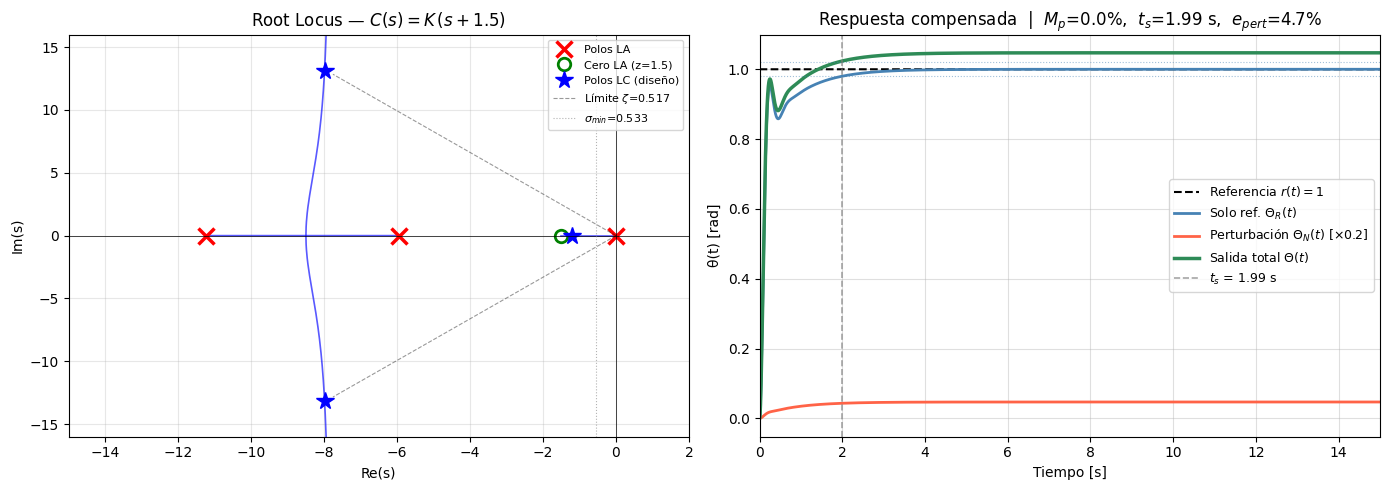

  SISTEMA COMPENSADO  C(s) = 2.2643·(s + 1.5)
  Sobrepico          Mp  = 0.00 %      (req ≤ 15 %)
  Tiempo establec.   ts  = 1.99 s    (req ≤ 7.5 s) 
  Error pert. (0.2)  ess = 4.71 %    (req < 5 %) 


In [ ]:
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
G     = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
G_mec = ctrl.tf([Kt], [J, B, 0])
 
# controlador PD diseñado
z_ctrl = 1.5
K_ctrl = 2.2643
C = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
print(f"Controlador: C(s) = {K_ctrl:.4f}·(s + {z_ctrl})")
print(f"           = {K_ctrl:.4f}·s + {K_ctrl*z_ctrl:.4f}")
 
# verificacion de la cond de modulo
C_zero = ctrl.tf([1, z_ctrl], [1])
s_dom  = -1.198
val    = C_zero(s_dom) * G(s_dom)
print(f"\nCondición de ángulo en s* = {s_dom}:")
print(f"  ∠[(s+z)·G(s*)] = {np.angle(val, deg=True):.2f}°  (debe ser ±180°)")
 
K_verif = 1.0 / abs(val)
print(f"  K por condición de módulo = {K_verif:.4f}  (diseño: {K_ctrl})")
 
# sist en lazo cerrado compensado 
G_cl = ctrl.feedback(ctrl.series(C, G), 1)
print(f"\nPolos LC compensado: {np.round(ctrl.poles(G_cl), 4)}")
print(f"Ceros LC compensado: {np.round(ctrl.zeros(G_cl), 4)}")
 
T_N = ctrl.series(G_mec, ctrl.feedback(ctrl.tf([1],[1]), ctrl.series(C, G)))
 
# simulacion
t = np.linspace(0, 20, 10000)
_, y_ref  = ctrl.step_response(G_cl, T=t)
_, y_pert = ctrl.step_response(T_N,  T=t)
y_pert    = 0.2 * y_pert
y_total   = y_ref + y_pert
 
# metricas
y_inf  = y_ref[-1]
Mp = (np.max(y_ref) - y_inf) / y_inf * 100
fuera  = np.where((y_ref > y_inf*1.02) | (y_ref < y_inf*0.98))[0]
ts = t[fuera[-1]] if len(fuera) > 0 else 0.0
e_pert = abs(y_pert[-1]) * 100
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# root locus + mucho código de graficación para mostrar polos, ceros, región de especificaciones, etc. en el informe :)
ax1 = axes[0]
rlist, klist = ctrl.root_locus_plot(ctrl.series(C_zero, G), plot=False)
for branch in range(rlist.shape[1]):
    ax1.plot(np.real(rlist[:, branch]), np.imag(rlist[:, branch]), 'b-', lw=1.2, alpha=0.65)
poles_ol = ctrl.poles(ctrl.series(C_zero, G))
zeros_ol = ctrl.zeros(ctrl.series(C_zero, G))
poles_lc = ctrl.poles(G_cl)
ax1.plot(np.real(poles_ol), np.imag(poles_ol), 'rx', ms=11, mew=2.5, label='Polos LA')
ax1.plot(np.real(zeros_ol), np.imag(zeros_ol), 'go', ms=9, mew=2, mfc='none', label=f'Cero LA (z={z_ctrl})')
ax1.plot(np.real(poles_lc), np.imag(poles_lc), 'b*', ms=13, label='Polos LC (diseño)')

# Región de specs: zeta >= 0.517 (Mp <= 15%)
theta_spec = np.arccos(0.517)
r_max = 15
ax1.plot([0, -r_max*np.cos(theta_spec)], [0,  r_max*np.sin(theta_spec)], 'k--', lw=0.8, alpha=0.4, label='Límite $\\zeta$=0.517')
ax1.plot([0, -r_max*np.cos(theta_spec)], [0, -r_max*np.sin(theta_spec)], 'k--', lw=0.8, alpha=0.4)
ax1.axhline(0, color='k', lw=0.5)
ax1.axvline(0, color='k', lw=0.5)
ax1.axvline(-4/7.5, color='gray', lw=0.8, ls=':', alpha=0.6, label='$\\sigma_{min}$=0.533')
ax1.set_xlim(-15, 2); ax1.set_ylim(-16, 16)
ax1.set_xlabel('Re(s)'); ax1.set_ylabel('Im(s)')
ax1.set_title(f'Root Locus — $C(s) = K\\,(s+{z_ctrl})$')
ax1.legend(fontsize=8, loc='upper right'); ax1.grid(True, alpha=0.3)
 
# respuesta al escalón 
ax2 = axes[1]
ax2.plot(t, np.ones_like(t), 'k--', lw=1.5, label='Referencia $r(t)=1$')
ax2.plot(t, y_ref,   color='steelblue', lw=2,   label='Solo ref. $\\Theta_R(t)$')
ax2.plot(t, y_pert,  color='tomato',    lw=2,   label='Perturbación $\\Theta_N(t)$ [×0.2]')
ax2.plot(t, y_total, color='seagreen',  lw=2.5, label='Salida total $\\Theta(t)$')
ax2.axhline(y_inf*1.02, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2.axhline(y_inf*0.98, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2.axvline(ts, color='gray', lw=1.2, ls='--', alpha=0.7, label=f'$t_s$ = {ts:.2f} s')
ax2.set_xlim(0, 15)
ax2.set_xlabel('Tiempo [s]'); ax2.set_ylabel('θ(t) [rad]')
ax2.set_title(f'Respuesta compensada  |  $M_p$={Mp:.1f}%,  $t_s$={ts:.2f} s,  $e_{{pert}}$={e_pert:.1f}%')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
 
plt.tight_layout()
plt.show()
 
print("  SISTEMA COMPENSADO  C(s) = 2.2643·(s + 1.5)")
print(f"  Sobrepico          Mp  = {Mp:.2f} %      (req ≤ 15 %)")
print(f"  Tiempo establec.   ts  = {ts:.2f} s    (req ≤ 7.5 s) ")
print(f"  Error pert. (0.2)  ess = {e_pert:.2f} %    (req < 5 %) ")

El controlador PD $C(s) = 2{,}2643\,(s + 1{,}5)$ cumple simultáneamente las tres
especificaciones. El cero en $s = -1{,}5$ modifica el Root Locus de manera que:
 
- La rama que partía del origen queda **atraída hacia $-1{,}5$**, produciendo un polo
  real dominante en $s \approx -1{,}198$.
- Las otras dos ramas forman un par complejo **muy rápido** en $s \approx -7{,}98 \pm j13{,}1$,
  que prácticamente no afecta la respuesta visible.
El polo dominante real produce una **respuesta exponencial sin sobrepico**, lo que
explica el $M_p \approx 0\,\%$. El producto $K \cdot z = 3{,}397 > 2{,}8$ garantiza
que el error ante perturbación quede por debajo del 5 % requerido.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso c</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Efecto del compensador PD sobre los márgenes de estabilidad
 
El controlador $C(s) = K(s+z)$ modifica el sistema de lazo abierto de dos formas:
 
**Sobre la fase:** el cero en $s = -z$ aporta adelanto de fase positivo para $\omega > 0$. La contribución máxima del cero es $+90°$ (asintótica), con aporte significativo en el rango $\omega \sim z = 1{,}5$ rad/s. Esto eleva la curva de fase del sistema compensado respecto al sin compensar.
 
**Sobre la magnitud:** la ganancia $K = 2{,}2643$ y el factor $|j\omega + z|$ elevan la curva de magnitud, desplazando $\omega_{gc}$ hacia frecuencias más altas.
 
**Sobre el GM:** el PD agrega un cero pero ningún polo, por lo que la fase del sistema compensado nunca llega a cruzar $-180°$ para frecuencias finitas. Esto hace que $\omega_{pc} \to \infty$ y, consecuentemente, $GM \to \infty$. El sistema compensado es **incondicionalmente estable** en lo que respecta al margen de ganancia.

┌─────────────────────────────────────────────────────────┐
│          MÁRGENES DE ESTABILIDAD — LAZO ABIERTO         │
├──────────────────────┬──────────────────┬───────────────┤
│                      │  Sin compensar   │  Compensado   │
├──────────────────────┼──────────────────┼───────────────┤
│  Margen de fase PM   │     72.22 °     │    67.29 °    │
│  ω_gc  [rad/s]       │    1.2174      │  10.7326     │
│  Margen de ganancia  │     22.76 dB    │  infinito dB    │
│  ω_pc  [rad/s]       │    8.1650      │  infinito       │
└──────────────────────┴──────────────────┴───────────────┘


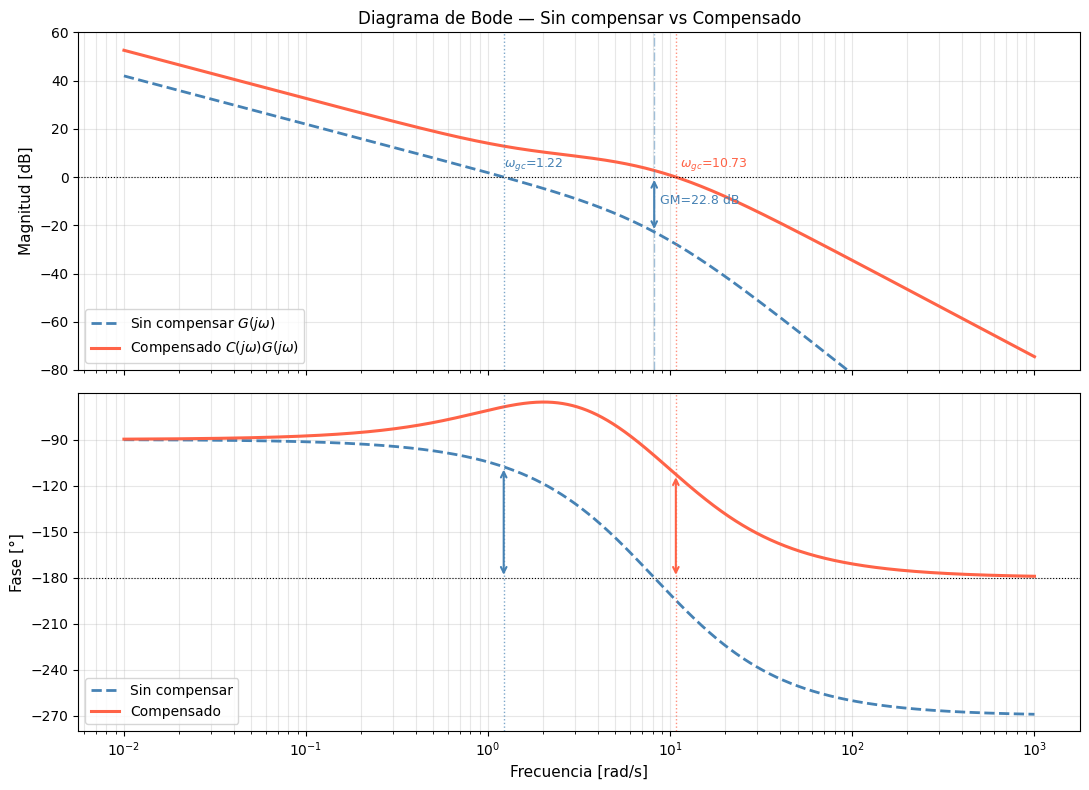

In [ ]:
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
# planta y controlador
G = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
z_ctrl = 1.5;   K_ctrl = 2.2643
C = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
CG = ctrl.series(C, G)
 
# hacemos el calculo de márgenes para ambos casos (sin compensar y compensado)
gm_raw,  pm_raw,  wpc_raw,  wgc_raw  = ctrl.margin(G)
gm_comp, pm_comp, wpc_comp, wgc_comp = ctrl.margin(CG)
 
print("┌─────────────────────────────────────────────────────────┐")
print("│          MÁRGENES DE ESTABILIDAD — LAZO ABIERTO         │")
print("├──────────────────────┬──────────────────┬───────────────┤")
print("│                      │  Sin compensar   │  Compensado   │")
print("├──────────────────────┼──────────────────┼───────────────┤")
print(f"│  Margen de fase PM   │  {pm_raw:>8.2f} °     │  {pm_comp:>7.2f} °    │")
print(f"│  ω_gc  [rad/s]       │  {wgc_raw:>8.4f}      │  {wgc_comp:>7.4f}     │")
print(f"│  Margen de ganancia  │  {20*np.log10(gm_raw):>8.2f} dB    │  {'infinito':>7s} dB    │")
print(f"│  ω_pc  [rad/s]       │  {wpc_raw:>8.4f}      │  {'infinito':>7s}       │")
print("└──────────────────────┴──────────────────┴───────────────┘")
 
# evaualmos en frecuencia manualmente
omega = np.logspace(-2, 3, 3000)
G_jw = G(1j * omega)
CG_jw = CG(1j * omega)
 
mag_G = 20 * np.log10(np.abs(G_jw))
mag_CG = 20 * np.log10(np.abs(CG_jw))
phase_G = np.unwrap(np.angle(G_jw,  deg=False)) * 180 / np.pi
phase_CG = np.unwrap(np.angle(CG_jw, deg=False)) * 180 / np.pi
 
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
 
ax1 = axes[0]
ax1.semilogx(omega, mag_G,  color='steelblue', lw=2, ls='--', label='Sin compensar $G(j\\omega)$')
ax1.semilogx(omega, mag_CG, color='tomato', lw=2.2, label='Compensado $C(j\\omega)G(j\\omega)$')
ax1.axhline(0, color='k', lw=0.8, ls=':')

ax1.axvline(wgc_raw, color='steelblue', lw=1, ls=':', alpha=0.7)
ax1.axvline(wgc_comp, color='tomato', lw=1, ls=':', alpha=0.7)
ax1.annotate(f'$\\omega_{{gc}}$={wgc_raw:.2f}', xy=(wgc_raw, 4), color='steelblue', fontsize=9)
ax1.annotate(f'$\\omega_{{gc}}$={wgc_comp:.2f}', xy=(wgc_comp * 1.05, 4), color='tomato', fontsize=9)
 
ax1.axvline(wpc_raw, color='steelblue', lw=1, ls='-.', alpha=0.5)
mag_G_at_wpc = float(np.interp(wpc_raw, omega, mag_G))
ax1.annotate('', xy=(wpc_raw, 0), xytext=(wpc_raw, mag_G_at_wpc),arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax1.annotate(f'GM={20*np.log10(gm_raw):.1f} dB', xy=(wpc_raw * 1.08, mag_G_at_wpc / 2), color='steelblue', fontsize=9)
 
ax1.set_ylabel('Magnitud [dB]', fontsize=11)
ax1.set_title('Diagrama de Bode — Sin compensar vs Compensado', fontsize=12)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylim(-80, 60)

ax2 = axes[1]
ax2.semilogx(omega, phase_G, color='steelblue', lw=2, ls='--', label='Sin compensar')
ax2.semilogx(omega, phase_CG, color='tomato', lw=2.2, label='Compensado')
ax2.axhline(-180, color='k', lw=0.8, ls=':')
 
phase_G_at_wgc = float(np.interp(wgc_raw, omega, phase_G))
ax2.axvline(wgc_raw, color='steelblue', lw=1, ls=':', alpha=0.7)
ax2.annotate('', xy=(wgc_raw, -180), xytext=(wgc_raw, phase_G_at_wgc), arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax2.annotate(f'PM={pm_raw:.1f}°', xy=(wgc_raw * 1.08, (phase_G_at_wgc - 180) / 2 - 180), color='steelblue', fontsize=9)
 
phase_CG_at_wgc = float(np.interp(wgc_comp, omega, phase_CG))
ax2.axvline(wgc_comp, color='tomato', lw=1, ls=':', alpha=0.7)
ax2.annotate('', xy=(wgc_comp, -180), xytext=(wgc_comp, phase_CG_at_wgc), arrowprops=dict(arrowstyle='<->', color='tomato', lw=1.5))
ax2.annotate(f'PM={pm_comp:.1f}°', xy=(wgc_comp * 1.08, (phase_CG_at_wgc - 180) / 2 - 180), color='tomato', fontsize=9)
 
ax2.set_ylabel('Fase [°]', fontsize=11)
ax2.set_xlabel('Frecuencia [rad/s]', fontsize=11)
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, which='both', alpha=0.3)
ax2.set_ylim(-280, -60)
ax2.set_yticks([-270, -240, -210, -180, -150, -120, -90])
 
plt.tight_layout()
plt.show()

Conclusiones sobre los márgenes de estabilidad

**Margen de fase:** el PM disminuye levemente de 72° a 67°. Esto ocurre porque la
ganancia K desplaza la frecuencia de cruce de ganancia $\omega_{gc}$ hacia valores
más altos (de 1.22 a 10.73 rad/s), donde la fase natural del sistema es menor.
El cero introducido por el compensador PD aporta adelanto de fase, pero no
compensa completamente esta caída. Aun así, el margen de fase resultante
(**67°**) sigue siendo ampliamente superior al mínimo recomendado, garantizando
una buena estabilidad relativa.

**Margen de ganancia:** el sistema compensado no presenta cruce de fase en
$-180^\circ$ para ninguna frecuencia finita. Como consecuencia,
$\omega_{pc} \to \infty$ y el margen de ganancia resulta infinito.
Esto indica que, para el modelo analizado, el sistema tolera incrementos de
ganancia sin perder estabilidad.

> En conclusión, el compensador PD permite cumplir con las especificaciones de
> desempeño del sistema, manteniendo márgenes de estabilidad elevados. Si bien el
> margen de fase se reduce levemente, el sistema continúa siendo robusto y con
> buen comportamiento dinámico.
 

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso d</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

#### Respuesta a rampa unitaria
 
##### Tipo de sistema y error en régimen permanente
 
El sistema compensado $C(s)\,G(s)$ tiene **un polo en el origen** (heredado de la planta), lo que lo convierte en un sistema de **tipo 1**. Para un sistema de tipo 1, los errores en régimen permanente son:
 
| Entrada | Error $e_{ss}$ |
|---|---|
| Escalón | 0 |
| Rampa | $1/K_v$ |
| Parábola | $\infty$ |
 
donde $K_v$ es la **constante de error de velocidad**:
 
$$K_v = \lim_{s \to 0}\, s\, C(s)\, G(s)$$
 
Sustituyendo $C(s) = K(s+z)$ y $G(s) = \dfrac{K_t}{s\,(Ls+R)(Js+B)+s\,K_e K_t}$, el polo en $s=0$ se cancela con el $s$ externo:
 
$$K_v = \lim_{s \to 0}\, K(s+z) \cdot \frac{K_t}{(Ls+R)(Js+B) + K_e K_t} = \frac{K \cdot z \cdot K_t}{R \cdot B + K_e K_t}$$
 
Con los valores del diseño ($K = 2{,}2643$, $z = 1{,}5$):
 
$$K_v = \frac{2{,}2643 \times 1{,}5 \times 0{,}25}{0{,}7 \times 0{,}25 + 0{,}1 \times 0{,}25} = \frac{0{,}8491}{0{,}2} = 4{,}246\,\text{rad}^{-1}$$
 
El error en régimen permanente ante la rampa unitaria es entonces:
 
$$\boxed{e_{ss} = \frac{1}{K_v} = \frac{1}{4{,}246} \approx 0{,}2355\,\text{rad}}$$
 
El sistema **sigue la rampa** pero con un **desfasaje angular constante** de 0.24 rad. Esto significa que el ángulo del aspa siempre va a estar ligeramente por detrás de la referencia en régimen permanente.
 
Para lograr seguimiento con error nulo ante rampa sería necesario que el sistema fuera de **tipo 2** (dos integradores en lazo abierto), lo que se aborda en el inciso e).

Constante de velocidad:  Kv  = 4.2456 rad⁻¹
Error régimen permanente: ess = 1/Kv = 0.2355 rad

Error simulado en t = 20 s: 0.2355 rad
Error simulado en t = 30 s: 0.2355 rad
Convergencia a 1/Kv = 0.2355 rad


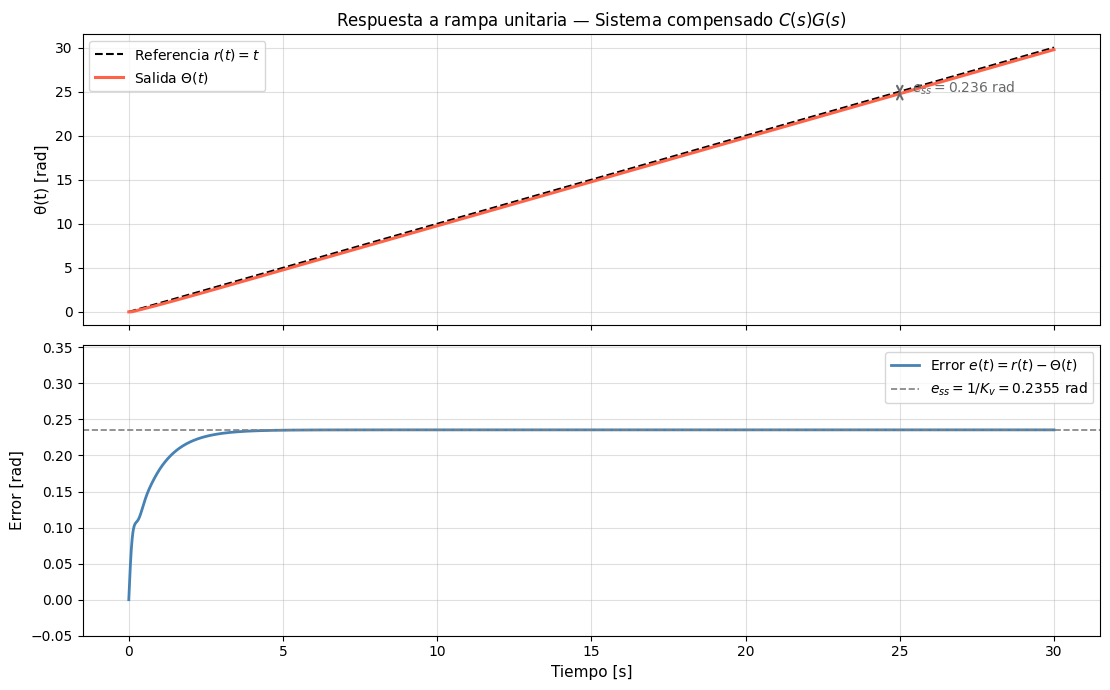

In [ ]:
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
G = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
z_ctrl = 1.5;   K_ctrl = 2.2643
C = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
G_cl = ctrl.feedback(ctrl.series(C, G), 1)
 
# constante de error de velocidad Kv 
Kv = K_ctrl * z_ctrl * Kt / (R * B + Ke * Kt)
e_ss = 1.0 / Kv
print(f"Constante de velocidad:  Kv  = {Kv:.4f} rad⁻¹")
print(f"Error régimen permanente: ess = 1/Kv = {e_ss:.4f} rad")
 
# simulacion con rampa unitaria 
t = np.linspace(0, 30, 10000)
ramp = t
 
t_out, y_ramp = ctrl.forced_response(G_cl, T=t, U=ramp)
error_t  = t_out - y_ramp
 
print(f"\nError simulado en t = 20 s: {np.interp(20, t_out, error_t):.4f} rad")
print(f"Error simulado en t = 30 s: {np.interp(30, t_out, error_t):.4f} rad")
print(f"Convergencia a 1/Kv = {e_ss:.4f} rad")
 
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
 
ax1 = axes[0]
ax1.plot(t_out, t_out,   'k--', lw=1.5, label='Referencia $r(t) = t$')
ax1.plot(t_out, y_ramp, color='tomato', lw=2.2, label='Salida $\\Theta(t)$')
 
t_mark = 25
y_mark = float(np.interp(t_mark, t_out, y_ramp))
ax1.annotate('', xy=(t_mark, t_mark), xytext=(t_mark, y_mark), arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax1.annotate(f'$e_{{ss}} = {e_ss:.3f}$ rad', xy=(t_mark + 0.4, (t_mark + y_mark) / 2), color='dimgray', fontsize=10)
 
ax1.set_ylabel('θ(t) [rad]', fontsize=11)
ax1.set_title('Respuesta a rampa unitaria — Sistema compensado $C(s)G(s)$', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)
 
ax2 = axes[1]
ax2.plot(t_out, error_t, color='steelblue', lw=2, label='Error $e(t) = r(t) - \\Theta(t)$')
ax2.axhline(e_ss, color='gray', lw=1.2, ls='--', label=f'$e_{{ss}} = 1/K_v = {e_ss:.4f}$ rad')
ax2.set_xlabel('Tiempo [s]', fontsize=11)
ax2.set_ylabel('Error [rad]', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)
ax2.set_ylim(-0.05, e_ss * 1.5)
 
plt.tight_layout()
plt.show()

El sistema sigue la rampa pero con un desfasaje angular constante de aproximadamente 0.2355 rad. 

Esto significa que el ángulo del aspa siempre va a estar ligeramente por detrás de la referencia en régimen permanente.

Este comportamiento es consistente con un sistema de tipo 1, el cual presenta error finito ante una entrada tipo rampa.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso e</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Controlador PID para seguimiento de rampa

El PD validado en el inciso anterior es de tipo 0, por lo que el lazo abierto
$C_{PD}(s)\,G(s)$ resulta de tipo 1 y presenta error constante $e_{ss} = 1/K_v \approx 0{,}236$ rad
ante rampa. Para eliminarlo se agrega un integrador al PD, convirtiéndolo en un PID:

$$C_{\mathrm{nuevo}}(s) = 2{,}0\,\frac{(s+1{,}5)(s+0{,}1)}{s}
= \frac{2{,}0\,s^2+3{,}2\,s+0{,}3}{s}$$

El cero $z_2 = 0{,}1$ se ubica cerca del nuevo polo en $s=0$ para producir una
cancelación aproximada que preserva la dinámica del diseño original.
El lazo abierto pasa a tener **dos integradores** → sistema de **tipo 2** → error
nulo ante rampa.

El código verifica el tipo del sistema, calcula las métricas de desempeño al escalón,
simula la respuesta a rampa y grafica el Root Locus junto con la evolución del error.

De nuevo, todo el detalle se encuentra desarrollado en el informe.

Controlador PID:
  C(s) = 2.0·(s+1.5)·(s+0.1) / s
       = (2.0·s² + 3.200·s + 0.300) / s

Integradores en lazo abierto: 2  -  sistema tipo 2
Error en régimen permanente ante rampa: 0 (exacto)

Polos LC: [-7.9631+12.2494j -7.9631-12.2494j -1.1376 +0.j     -0.103  +0.j    ]
Ceros LC: [-1.5+0.j -0.1+0.j]
  SPECS — CONTROLADOR PID
  Sobrepico    Mp  = 1.36 %    (req ≤ 15 %)
  Tiempo est.  ts  = 1.64 s    (req ≤ 7.5 s)
  Error pert.  ess = 0.76 %    (req < 5 %)
  Error rampa  ess = 0.000078 rad  (req = 0)

  Nota: polo lento en s≈-0.103 - transitorio de rampa dura ≈39 s


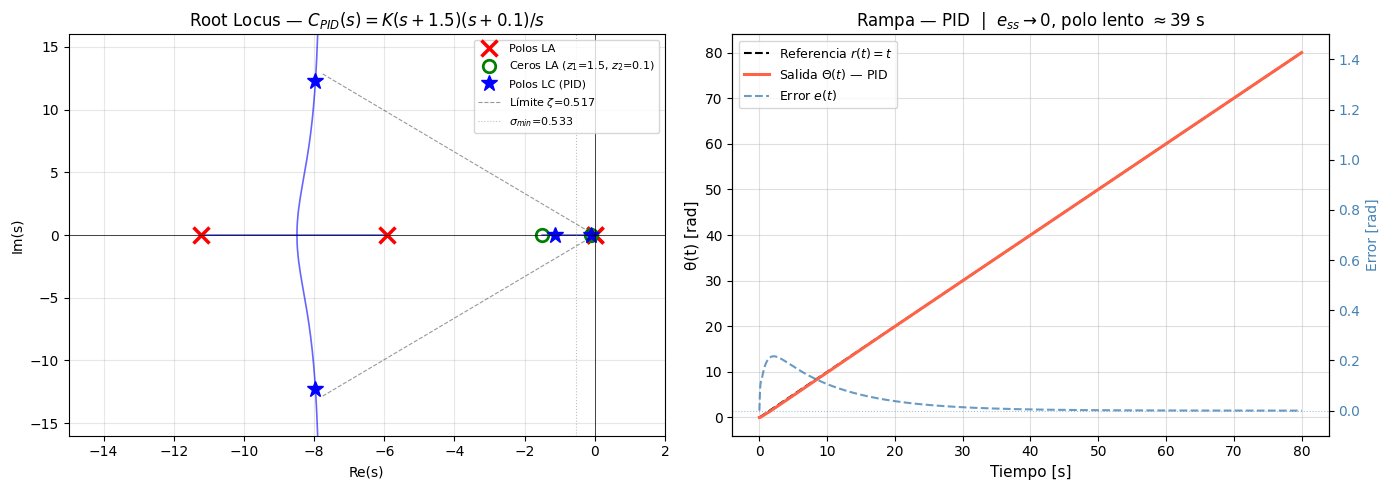

In [ ]:
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25

G = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
G_mec = ctrl.tf([Kt], [J, B, 0])
 
# controlador PID !
z1 = 1.5;  z2 = 0.1;  K_pid = 2.0
 
num_C = [K_pid, K_pid*(z1+z2), K_pid*z1*z2]
den_C = [1, 0]
C_pid = ctrl.tf(num_C, den_C)
 
print("Controlador PID:")
print(f"  C(s) = {K_pid}·(s+{z1})·(s+{z2}) / s")
print(f"   = ({num_C[0]}·s² + {num_C[1]:.3f}·s + {num_C[2]:.3f}) / s")
 
# verif de tipo del sistema
CG = ctrl.series(C_pid, G)
poles_CG = ctrl.poles(CG)
n_int = sum(1 for p in poles_CG if abs(p) < 1e-6)
print(f"\nIntegradores en lazo abierto: {n_int}  -  sistema tipo {n_int}")
print(f"Error en régimen permanente ante rampa: {'0 (exacto)' if n_int >= 2 else '1/Kv ≠ 0'}")
 
# sist en lazo cerrado
G_cl = ctrl.feedback(ctrl.series(C_pid, G), 1)
T_N  = ctrl.series(G_mec, ctrl.feedback(ctrl.tf([1],[1]), ctrl.series(C_pid, G)))
 
print(f"\nPolos LC: {np.round(ctrl.poles(G_cl), 4)}")
print(f"Ceros LC: {np.round(ctrl.zeros(G_cl), 4)}")
 
# simulacion — escalon + perturb
t_step = np.linspace(0, 20, 10000)
_, y_step = ctrl.step_response(G_cl, T=t_step)
_, y_pert = ctrl.step_response(T_N,  T=t_step)
y_pert = 0.2 * y_pert
 
y_inf = y_step[-1]
Mp = (np.max(y_step) - y_inf) / y_inf * 100
fuera = np.where((y_step > y_inf*1.02) | (y_step < y_inf*0.98))[0]
ts = t_step[fuera[-1]] if len(fuera) > 0 else 0.0
ep = abs(y_pert[-1]) * 100
 
# simulacion rampa (nos fijamos t largo para ver convergencia)
t_ramp  = np.linspace(0, 80, 20000)
t_r, y_ramp = ctrl.forced_response(G_cl, T=t_ramp, U=t_ramp)
error_ramp = t_r - y_ramp
ess_ramp_sim = abs(error_ramp[-1])

print("  SPECS — CONTROLADOR PID")
print(f"  Sobrepico    Mp  = {Mp:.2f} %    (req ≤ 15 %)")
print(f"  Tiempo est.  ts  = {ts:.2f} s    (req ≤ 7.5 s)")
print(f"  Error pert.  ess = {ep:.2f} %    (req < 5 %)")
print(f"  Error rampa  ess = {ess_ramp_sim:.6f} rad  (req = 0)")
print(f"\n  Nota: polo lento en s≈-0.103 - transitorio de rampa dura ≈{4/0.103:.0f} s")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ax1 = axes[0]
CG_nok = ctrl.series(ctrl.tf([1, z1+z2, z1*z2], [1, 0]), G)
try:
    rlist, klist = ctrl.root_locus_plot(CG_nok, plot=False)
    for branch in range(rlist.shape[1]):
        ax1.plot(np.real(rlist[:, branch]), np.imag(rlist[:, branch]),
                 'b-', lw=1.2, alpha=0.6)
except: pass
 
poles_ol = ctrl.poles(CG_nok)
zeros_ol = ctrl.zeros(CG_nok)
poles_lc = ctrl.poles(G_cl)
ax1.plot(np.real(poles_ol), np.imag(poles_ol), 'rx', ms=11, mew=2.5, label='Polos LA')
ax1.plot(np.real(zeros_ol), np.imag(zeros_ol), 'go', ms=9, mew=2, mfc='none', label=f'Ceros LA ($z_1$={z1}, $z_2$={z2})')
ax1.plot(np.real(poles_lc), np.imag(poles_lc), 'b*', ms=12, label='Polos LC (PID)')
 
theta_spec = np.arccos(0.517); r_max = 15
ax1.plot([0, -r_max*np.cos(theta_spec)], [0,  r_max*np.sin(theta_spec)], 'k--', lw=0.8, alpha=0.4, label='Límite $\\zeta$=0.517')
ax1.plot([0, -r_max*np.cos(theta_spec)], [0, -r_max*np.sin(theta_spec)], 'k--', lw=0.8, alpha=0.4)
ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)
ax1.axvline(-4/7.5, color='gray', lw=0.8, ls=':', alpha=0.5, label='$\\sigma_{min}$=0.533')
ax1.set_xlim(-15, 2); ax1.set_ylim(-16, 16)
ax1.set_xlabel('Re(s)'); ax1.set_ylabel('Im(s)')
ax1.set_title(f'Root Locus — $C_{{PID}}(s) = K(s+{z1})(s+{z2})/s$')
ax1.legend(fontsize=8, loc='upper right'); ax1.grid(True, alpha=0.3)
 
ax2 = axes[1]
ax2.plot(t_r, t_r,    'k--', lw=1.5, label='Referencia $r(t)=t$')
ax2.plot(t_r, y_ramp, color='tomato', lw=2.2, label='Salida $\\Theta(t)$ — PID')
 
ax2b = ax2.twinx()
ax2b.plot(t_r, error_ramp, color='steelblue', lw=1.5, ls='--', alpha=0.8, label='Error $e(t)$')
ax2b.axhline(0, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2b.set_ylabel('Error [rad]', color='steelblue', fontsize=10)
ax2b.tick_params(axis='y', labelcolor='steelblue')
ax2b.set_ylim(-0.1, 1.5)
 
ax2.set_xlabel('Tiempo [s]', fontsize=11)
ax2.set_ylabel('θ(t) [rad]', fontsize=11)
ax2.set_title(f'Rampa — PID  |  $e_{{ss}}\\to 0$, polo lento $\\approx${4/0.103:.0f} s', fontsize=12)
 
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.4)
 
plt.tight_layout()
plt.show()

El controlador modificado $C_{nuevo}(s) = 2{,}0\,(s+1{,}5)(s+0{,}1)/s$ resuelve el
problema de seguimiento de rampa **sin violar ninguna de las especificaciones anteriores**.
 
### Tabla comparativa de los 3 casos
 
| Especificación | Req. | Sin compensar | PD | **PID** |
|---|---|---|---|---|
| $M_p$ | ≤ 15 % | 0.02 % | 0.00 % | **1.36 %** |
| $t_s$ | ≤ 7.5 s | 2.05 s | 1.99 s | **1.64 s** |
| Error pert. (0.2) | < 5 % | 14.00 % | 4.71 % | **0.76 %** |
| Error ante rampa | = 0 | 0.235 rad | 0.235 rad | **0 rad** |
  
**¿Por qué funciona?** El integrador agregado en el controlador lleva el sistema de tipo 1
a **tipo 2**: el lazo abierto tiene ahora dos polos en el origen, lo que garantiza error
nulo ante cualquier rampa. El cero en $z_2 = 0{,}1$ se ubica muy cerca del nuevo polo en
el origen, produciendo una **cancelación aproximada** que preserva la dinámica
rápida del diseño con PD.
 
**El polo lento en $s \approx -0{,}103$** es consecuencia inevitable del integrador adicional.
Tiene un tiempo de establecimiento de ~39 s, pero solo afecta la respuesta a rampa
(el error converge lentamente a cero). Para la respuesta al escalón, el cero del
lazo cerrado en $s = -0{,}1$ casi lo cancela y el transitorio sigue siendo rápido.
 
**El error ante perturbación mejora significativamente** (de 4.71% a 0.76%) porque
el integrador en el controlador elimina el efecto de cargas constantes en régimen
permanente — es el mismo principio que el controlador PI clásico.

<div style="display:flex; align-items:center; gap:14px; margin:24px 0;">
  <div style="height:2px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <span style="
    background:#105666;
    color:#f5ede8;
    font-family:'Georgia',serif;
    font-size:0.75em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:6px 18px;
    border-radius:20px;
  ">Segunda parte</span>
  <div style="height:2px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

### Análisis y Control frente a Perturbaciones

Durante ensayos en túnel de viento, se detectó que el coeficiente de fricción viscosa
$B$ puede degradarse por fatiga del material o variaciones térmicas, llegando incluso
a tomar **valores negativos** y comprometiendo la estabilidad del sistema.

Para este análisis se utiliza un modelo simplificado que desprecia la dinámica eléctrica
(asumiendo que su constante de tiempo es significativamente menor que la mecánica),
quedando el sistema descripto por:

$$G(s) = \frac{\Theta(s)}{V(s)} = \frac{K}{s(Js + B)}$$

con $K = 1$ y $J = 1$. El parámetro $B$ es la fuente de incertidumbre: en condiciones
nominales $B = 0{,}5$, pero ante la falla modelada cae a $B = -0{,}1$.

El análisis se divide en dos partes. En la **Parte A** se caracteriza la sensibilidad
del sistema frente a esta falla: se estudia la estabilidad mediante el criterio de
Nyquist, se simula la transición abrupta entre el sistema nominal y el fallado, y se
analiza el desplazamiento de los polos en el lugar de raíces para entender por qué
el sistema colapsa. En la **Parte B** se diseña un compensador que incremente los
**márgenes de fase** del sistema nominal a $35°$, $50°$ y $65°$, garantizando
estabilidad robusta aun cuando $B$ tome valores negativos, y se analiza el impacto
de cada nivel de margen sobre la respuesta transitoria del sistema.

### Parte A - Análisis de Sensibilidad y Robustez
Se caracteriza el comportamiento del sistema frente a la degradación del parámetro $B$.
Partiendo del sistema nominal ($B = 0{,}5$) con realimentación unitaria, se analiza la
estabilidad mediante el **criterio de Nyquist** y se simula la respuesta al escalón
ante una falla abrupta en $t = 15\,\text{s}$, donde $B$ pasa de $0{,}5$ a $-0{,}1$.
El estudio del **lugar de raíces** para ambos casos permite entender el desplazamiento
de los polos y explicar por qué el sistema, estable en condiciones nominales, colapsa
ante la degradación. Con base en estos resultados se justifica la elección del tipo de
compensador adecuado para otorgar robustez frente a esta variación paramétrica.

In [35]:
def plant(B_val):
    num = [1]
    den = [1, B_val, 0]
    return ctrl.tf(num, den)

In [36]:
G_B05 = plant(0.5)
G_B01 = plant(-0.1)

G_B05_closed = ctrl.feedback(G_B05, 1)
G_B01_closed = ctrl.feedback(G_B01, 1)

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso a</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

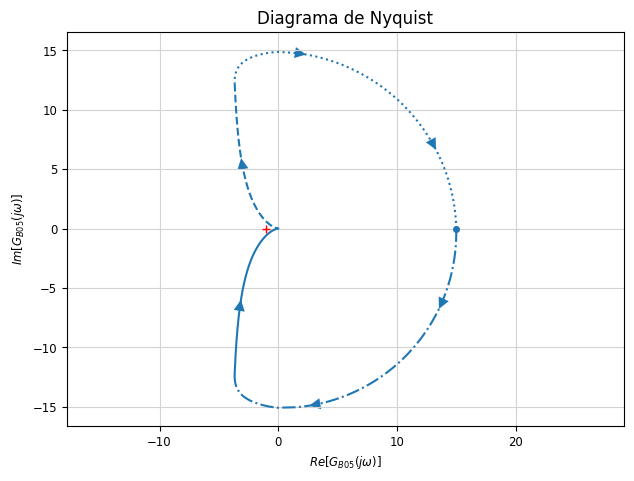

In [37]:
plt.figure()
ctrl.nyquist_plot(G_B05, title='')
plt.title('Diagrama de Nyquist')
plt.xlabel('$Re[G_{B05}(j\\omega)]$')
plt.ylabel('$Im[G_{B05}(j\\omega)]$')
plt.grid(True)
plt.axis('equal')
plt.show()

##### A partir del criterio de estabilidad de Nyquist, se puede observar que el sistema es estable en lazo cerrado:
- $P = 0$ (cantidad de polos del sistema a lazo abierto que estan en el RHP)
- $N = 0$ (cantidad de vueltas alrededor de $-1+j0$)
- $Z = P - N$ donde $Z$ es la cantidad de polos del sistema a lazo cerrado en el RHP, el cual es $Z = 0$

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso b</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

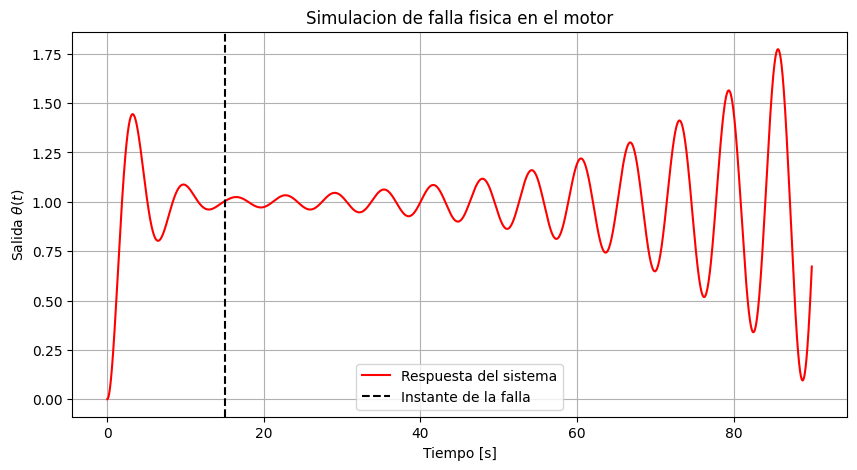

In [38]:
# Tiempos de simulacion
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 90, 3000)

# Sistema con B=0.5
sys1 = ctrl.ss(G_B05_closed)
response1 = ctrl.forced_response(sys1, T=t1, U=1)
t_out1 = response1.time
y_out1 = response1.outputs
x_out1 = response1.states
x_final_stage1 = x_out1[:, -1]

# Sistema con B=-0.1
sys2 = ctrl.ss(G_B01_closed)
response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
t_out2 = response2.time
y_out2 = response2.outputs
x_out2 = response2.states

t_total = np.concatenate([t_out1, t_out2])
y_total = np.concatenate([y_out1, y_out2])

plt.figure(figsize=(10, 5))
plt.plot(t_total, y_total, label='Respuesta del sistema', color='red')
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso c</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


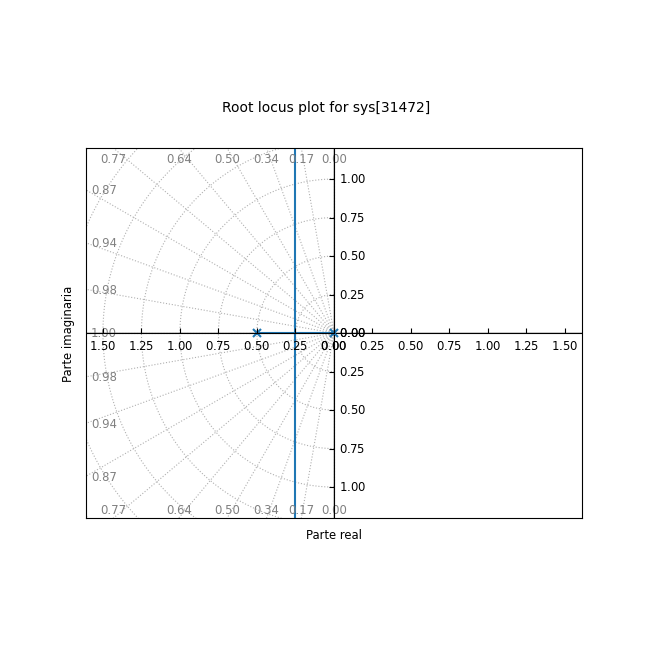

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


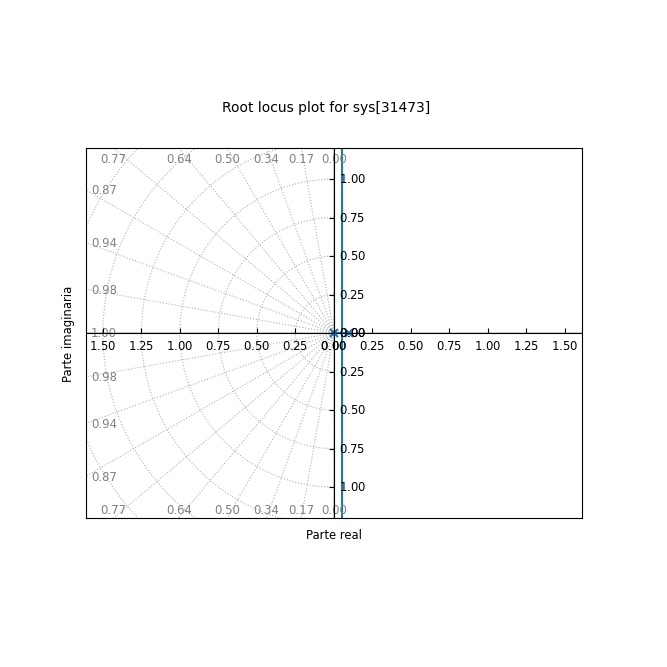

In [39]:
ctrl.root_locus(G_B05)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

ctrl.root_locus(G_B01)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

##### La estabilidad depende del valor de B: la función de transferencia es $\tfrac{K}{s(Js+B)}=\tfrac{1}{s(s+B)}$, los polos del sistema son $s=0$ y $s=-B$
##### De esta manera:
- Con $B>0$ el polo tiene parte real negativa, por lo que el sistema es estable.
- Con $B<0$ el polo tiene parte real positiva, por lo que el sistema es inestable.
- Con $B=0$ hay doble polo en cero, po rlo que el sistema se vuelve marginalmente estable (oscila).

##### En cuanto a la robustez, frente a un cambio pequeño que cruce el eje imaginario destruye el control del sistema. Además, incluso si $B$ se mantiene positivo, el sistema es sensible (si $B$ disminuye aparecen oscilaciones o sobrepicos y si aumenta mucho el sistema se vuelve muy lento)

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte A - inciso d</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

##### A partir de los resultados anteriores, el tipo de compensador que se considera adecuado es un compensador en adelanto. Esta elección se debe a que el sistema tiene un polo en el origen ($s=0$) que aporta -90° de fase, y un segundo polo en $s=-B$ el cual aporta de manera distinta a la fase:
- B>0: polo estable, la fase total tiende a -180° pero no la alcanza.
- B=0: polo doble en el origen, con fase constante de -180°, lo que hace que el sistema sea marginalmente estable (oscila).
- B<0: la fase cae por debajo de los -180°, por lo que convierte al sistema en inestable.
##### De esta manera, el compensador en adelanto agregaria fase positiva al sistema en lazo abierto, incrementando el margen de fase, permitiendo que el sistema soporte la falla.

---

### Parte B — Diseño de Compensador para Estabilidad Robusta

Se diseña el compensador seleccionado en la Parte A con el objetivo de incrementar el
**margen de fase** del sistema nominal ($B = 0{,}5$) a tres niveles: $35°$, $50°$ y
$65°$. En cada caso se normaliza la ganancia DC del compensador para no alterar el
error de posición en régimen permanente. Se verifican los márgenes obtenidos en el
**diagrama de Bode** y se simula la respuesta al escalón ante la falla en $t = 15\,\text{s}$,
comparando los tiempos de establecimiento entre los tres diseños. Finalmente, se analiza
el efecto del compensador sobre el **diagrama de Nyquist** y se discuten las desventajas
de incrementar indefinidamente el margen de fase.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso a</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

Para este inciso, se usó un compensador en adelanto de la forma $C(s) = k\tfrac{s+1}{s+k}$, el cual es un compensador normalizado que no genera cambios bruscos en la ganancia de estado estacionario, esto se puede ver con $lim_{s\rightarrow 0} C(s) = lim_{s\rightarrow 0} k\tfrac{s+1}{s+k} = 1$.  

Como un compensador en adelanto tiene el cero a la derecha del polo y este compensador tiene un cero en $s = -1$ y un polo en $s = -k$, entonces $k > 1$. Para el diseño del compensador, se varía el valor de k, desde 1.1, hasta llegar al valor del margen de fase deseado.  

Este tipo de compensador se puede usar porque permite aumentar el margen de fase del sistema, permitiendo la mejora en la estabilidad frente a variaciones de B. Introduce fase positiva, lo que ayuda a compensar el efecto de los polos de la planta que aportan fase negativa. Además, al estar normalizado no modifica el comportamiento en régimen permanente ni el error de estado estacionario.

In [40]:
def compensador(z):
    num = [z, z]
    den = [1, z]
    return ctrl.tf(num, den)

In [41]:
z_values = np.linspace(1.1, 50, 100000)
objetivos = [35, 50, 65]
z_encontrados = [None, None, None]

for z in z_values:
    C = compensador(z)
    L = C * G_B05
    _, pm, _, _ = ctrl.margin(L)

    for i, objetivo in enumerate(objetivos):
        if z_encontrados[i] is None and pm >= objetivo:
            z_encontrados[i] = z

    if all(v is not None for v in z_encontrados):
        break

print('Resultados:')
for objetivo, z in zip(objetivos, z_encontrados):
    print(f'Para MF={objetivo}°: z={z}')

Resultados:
Para MF=35°: z=1.360639606396064
Para MF=50°: z=2.746479464794648
Para MF=65°: z=8.745102451024511


<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso b</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

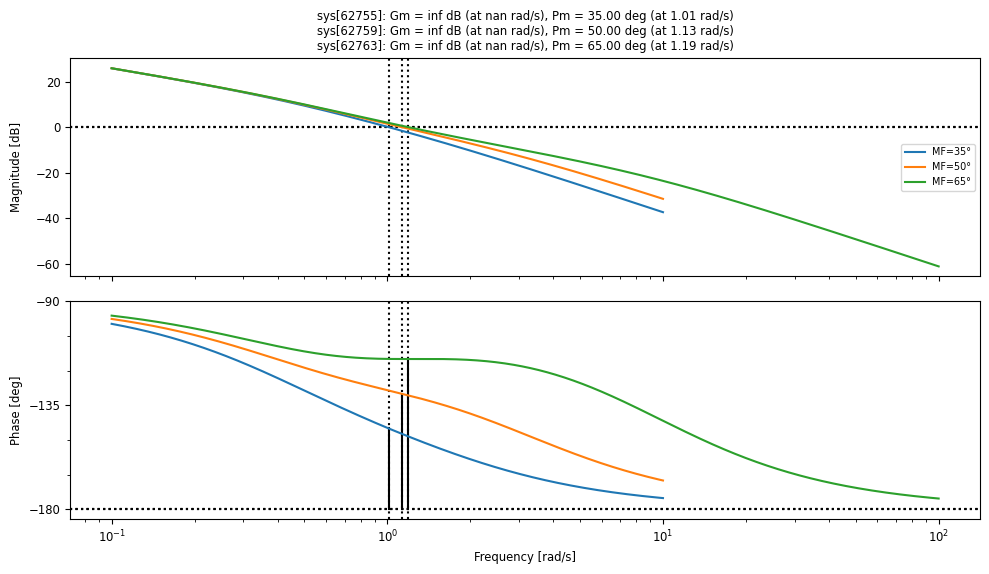

In [42]:
plt.figure(figsize=(10, 6))

for z in z_encontrados:
    C = compensador(z)
    L = C * G_B05
    
    gm, pm , wg , wp = ctrl.margin(L)
    
    ctrl.bode_plot(L, dB=True, deg=True, display_margins=True, label=f'MF={pm:.0f}°')

plt.show()

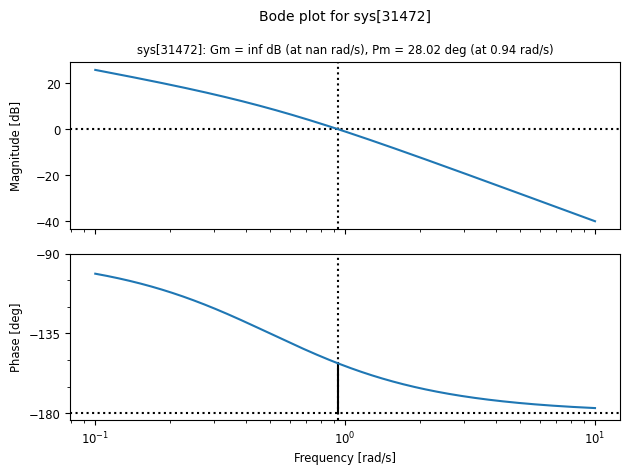

In [43]:
ctrl.bode_plot(G_B05, dB=True , deg=True , display_margins=True)
plt.show()

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso c</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

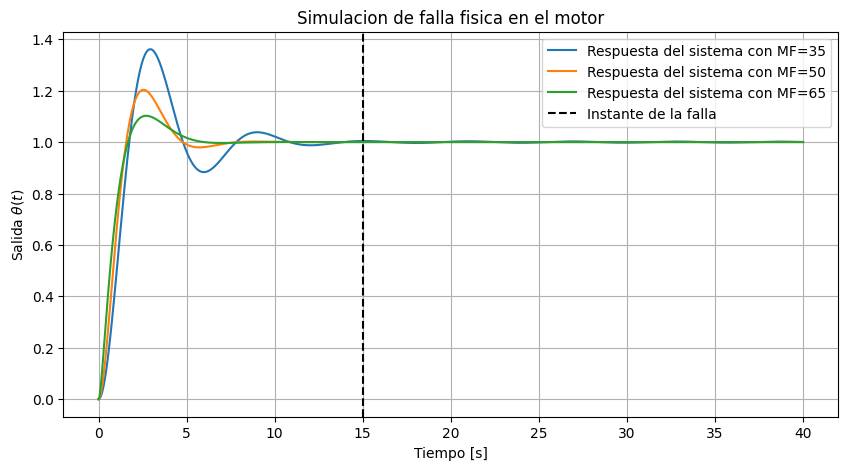

In [44]:
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 40, 3000)

plt.figure(figsize=(10, 5))

for z, label in zip(z_encontrados, objetivos):
    C = compensador(z)
    L_B05 = C * G_B05
    L_B01 = C * G_B01
    L_B05_closed = ctrl.feedback(L_B05, 1)
    L_B01_closed = ctrl.feedback(L_B01, 1)

    # Sistema con B=0.5
    sys1 = ctrl.ss(L_B05_closed)
    response1 = ctrl.forced_response(sys1, T=t1, U=1)
    t_out1 = response1.time
    y_out1 = response1.outputs
    x_out1 = response1.states
    x_final_stage1 = x_out1[:, -1]

    # Sistema con B=-0.1
    sys2 = ctrl.ss(L_B01_closed)
    response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
    t_out2 = response2.time
    y_out2 = response2.outputs
    x_out2 = response2.states

    t_total = np.concatenate([t_out1, t_out2])
    y_total = np.concatenate([y_out1, y_out2])

    plt.plot(t_total, y_total, label=f'Respuesta del sistema con MF={label}')
 
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

##### Análisis de tiempos de establecimiento
 
Los polos dominantes del lazo cerrado y los tiempos de establecimiento para cada compensador son:
 
| Compensador | $z$ | Polo dominante | $\zeta$ | $t_s$ nominal |
|---|---|---|---|---|
| MF = 35° | 1.361 | $-0.369 \pm j1.037$ | 0.335 | 9.90 s |
| MF = 50° | 2.747 | $-0.719 \pm j1.001$ | 0.584 | 5.95 s |
| MF = 65° | 8.745 | $-0.779 \pm j0.728$ | 0.731 | 4.87 s |
 
A medida que se incrementa el margen de fase, el factor de amortiguamiento $\zeta$ crece
y el tiempo de establecimiento **disminuye**: el sistema responde más rápido y con menos
oscilaciones. Esto se puede observar claramente en el gráfico: con MF = 35° la respuesta
presenta un sobrepico apreciable (~36%) y oscilaciones que se extienden hasta ~10 s;
con MF = 50° el sobrepico se reduce (~20%) y desaparece antes; con MF = 65° la
respuesta es casi monótona, con sobrepico mínimo (~10%) y establecimiento en ~5 s.
 
En el límite, cuando $\zeta \to 1$, el par de polos complejos conjugados se aproxima a
dos polos reales iguales. Por eso, **a mayor MF, el sistema se parece cada vez más a
un sistema críticamente amortiguado** ($\zeta = 1$): respuesta exponencial sin
oscilaciones, que alcanza el valor final de forma monótona.
 
En cuanto a la falla en $t = 15$ s: los tres sistemas ya se habían establecido antes de
que ocurra el cambio $B = 0{,}5 \to -0{,}1$, y los tres se mantienen estables después de
ella, convergiendo nuevamente a 1 rad. Esto confirma que el compensador lead otorga
el margen de seguridad necesario para tolerar la degradación del parámetro $B$.

<div style="display:flex; align-items:center; gap:14px; margin:32px 0 8px 0;">
  <div style="height:1.5px; flex:1; background:linear-gradient(to right, #D3968C, transparent);"></div>
  <div style="
    background:#105666;
    color:#f5ede8;
    font-family:monospace;
    font-size:0.72em;
    letter-spacing:3px;
    text-transform:uppercase;
    padding:7px 20px;
    border-radius:20px;
    border: 1px solid rgba(211,150,140,0.3);
  ">Parte B - inciso d</div>
  <div style="height:1.5px; flex:1; background:linear-gradient(to left, #D3968C, transparent);"></div>
</div>

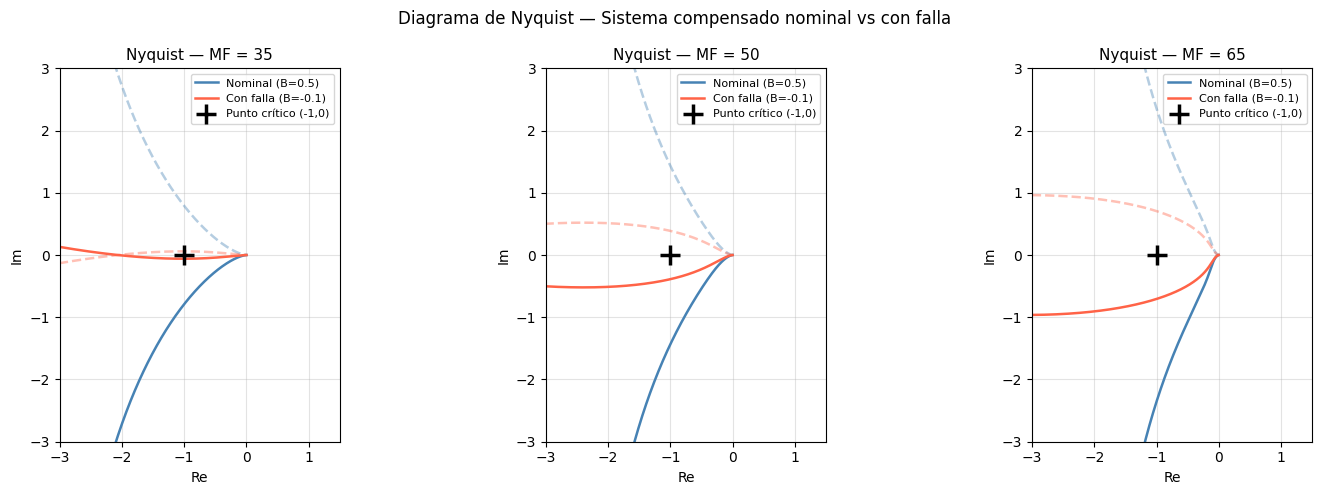

In [ ]:
omega = np.logspace(-2, 2, 2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, z, label in zip(axes, z_encontrados, objetivos):
    C = compensador(z)
    L = C * G_B05
    L_falla = C * G_B01

    # Evaluamos manualmente en jω !
    L_jw = np.array([L(1j*w) for w in omega])
    L_falla_jw = np.array([L_falla(1j*w) for w in omega])

    # graficamos las curvas para poder analiza en el informe
    ax.plot(np.real(L_jw), np.imag(L_jw), color='steelblue', lw=1.8, label='Nominal (B=0.5)')
    ax.plot(np.real(L_jw), -np.imag(L_jw), color='steelblue', lw=1.8, ls='--', alpha=0.4)

    ax.plot(np.real(L_falla_jw), np.imag(L_falla_jw), color='tomato', lw=1.8, label='Con falla (B=-0.1)')
    ax.plot(np.real(L_falla_jw), -np.imag(L_falla_jw), color='tomato', lw=1.8, ls='--', alpha=0.4)
    ax.plot(-1, 0, 'k+', ms=14, mew=2.5, label='Punto crítico (-1,0)')
    ax.set_title(f'Nyquist — MF = {label}', fontsize=11)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_xlim(-3, 1.5); ax.set_ylim(-3, 3)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.35)
    ax.set_aspect('equal')

plt.suptitle('Diagrama de Nyquist — Sistema compensado nominal vs con falla', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. ¿Cómo el compensador "aleja" la curva del punto crítico (-1, 0)?
 
El compensador en adelanto $C(s) = k\tfrac{s+1}{s+k}$ aporta **fase positiva** en el
rango de frecuencias cercano a $\omega_{gc}$. Esto produce un efecto geométrico directo
sobre el diagrama de Nyquist: la curva $C(j\omega)G(j\omega)$ se "rota" en sentido
antihorario respecto a la curva sin compensar $G(j\omega)$, alejándose del punto
crítico $(-1, 0)$.
 
En los diagramas se puede observar:
 
- **Sin compensar (Parte A):** la curva cruza el eje real negativo relativamente cerca
  de $-1$, dejando poco margen.
- **Compensado nominal (B=0.5, curva azul):** la curva pasa notoriamente más lejos de
  $(-1, 0)$ — ese alejamiento es exactamente el margen de fase ganado. A mayor MF
  diseñado, mayor es la distancia al punto crítico.
- **Con falla (B=-0.1, curva roja):** la degradación de $B$ deforma la curva y la
  acerca al punto crítico. Sin embargo, gracias al margen adicional introducido por el
  compensador, **la curva sigue sin rodearlo** ($N = 0$, $P = 0$, $Z = 0$), por lo que
  el sistema en lazo cerrado se mantiene estable.
A mayor MF diseñado, mayor es la distancia de seguridad entre la curva nominal y el
punto $(-1, 0)$, y mayor es el colchón disponible para tolerar la degradación de $B$.


##### 2. ¿Qué desventajas observa al seguir incrementando el MF?
 
Aumentar el margen de fase mediante este compensador implica aumentar el valor de $k$
(de 1.36 a 2.75 a 8.75 en nuestros tres casos), lo que tiene los siguientes efectos negativos:
 
- **Amplificación de ruido en altas frecuencias:** la ganancia del compensador tiende a
  $|C(j\omega)| \to k$ para $\omega \to \infty$. A mayor $k$, mayor es la amplificación
  del ruido de alta frecuencia en la señal de error, lo que deteriora el desempeño real
  del sistema implementado.
- **Mayor ancho de banda:** el desplazamiento de $\omega_{gc}$ hacia frecuencias más altas
  hace al sistema más sensible a dinámicas no modeladas como flexibilidad estructural,
  retardos de actuación o resonancias mecánicas.
- **Implementación física más exigente:** un compensador con $k$ muy grande requiere
  componentes con tiempos de respuesta muy rápidos (amplificadores, sensores de alta
  velocidad), lo que puede ser costoso o directamente irrealizable en la práctica.
- **Rendimiento decreciente:** como se observa en la tabla del inciso c), pasar de
  MF = 35° a 50° reduce el $t_s$ de 9.90 s a 5.95 s (mejora de ~4 s), pero pasar de
  50° a 65° solo lo reduce de 5.95 s a 4.87 s (mejora de apenas ~1 s), con un $k$ que
  casi se triplica (de 2.75 a 8.75). La ganancia en robustez se vuelve cada vez menor
  en relación al costo.
En conclusión, existe un **trade-off** entre robustez (mayor MF) y desempeño/practicidad:
no conviene seguir incrementando el MF indefinidamente más allá de lo necesario para
garantizar estabilidad ante la falla esperada.